# Stage 3 — Robustez multi-seed del protocolo cíclico

Congelamos sin cambios la receta que pasó en seed 0: EMA `0.90`, learning rate `4×` para `M`, freeze del encoder después de época 3, horizonte fijo de 60 épocas y checkpoint final.

La evaluamos sobre 10 seeds nuevas (`1–10`), variando conjuntamente inicialización y realización de datos. El gate agregado, fijado antes de ejecutar, exige al menos 8/10 éxitos y medianas de entrelazamiento y error espectral no mayores que `0.20`. Test no se construye.

In [1]:
# ruff: noqa: E402, E501, I001
import json
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import yaml
from IPython.display import Markdown, display

from koopman_jepa.config import DataConfig, ExperimentConfig, ModelConfig, TrainConfig, validate_config
from koopman_jepa.model import TemporalJEPA
from koopman_jepa.phase_analysis import evaluate_phase_operator_diagnostics, evaluate_phase_representation
from koopman_jepa.phase_data import PhaseWindowConfig, make_phase_tensor_dataset_splits
from koopman_jepa.training import collect_paired_embeddings, evaluate_model_loss, select_device, set_seed, train_model

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
REFERENCE_PATH = ROOT / "configs" / "stage3_cyclic_predictor_freeze_long_smoke.yaml"
CONFIG_PATH = ROOT / "configs" / "stage3_cyclic_multiseed_development.yaml"
with REFERENCE_PATH.open(encoding="utf-8") as handle:
    reference_raw = yaml.safe_load(handle)
with CONFIG_PATH.open(encoding="utf-8") as handle:
    raw = yaml.safe_load(handle)
seeds = raw["seeds"]
assert seeds == list(range(1, 11))
for key in ("dynamics", "emission", "splits", "model", "train", "selection", "gates"):
    assert raw[key] == reference_raw[key]
assert raw["aggregate_gates"] == {
    "minimum_successful_seeds": 8,
    "maximum_median_intertwining_error": 0.20,
    "maximum_median_spectral_error": 0.20,
}
emission_config = PhaseWindowConfig(**raw["emission"], repeats_per_transition=1)
model_raw = raw["model"]
print(json.dumps({"config": CONFIG_PATH.name, "seeds": seeds, "aggregate_gates": raw["aggregate_gates"], "test_constructed": False}, indent=2))

{
  "config": "stage3_cyclic_multiseed_development.yaml",
  "seeds": [
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10
  ],
  "aggregate_gates": {
    "minimum_successful_seeds": 8,
    "maximum_median_intertwining_error": 0.2,
    "maximum_median_spectral_error": 0.2
  },
  "test_constructed": false
}


In [3]:
def run_seed(seed):
    experiment_config = ExperimentConfig(
        data=DataConfig(context_length=emission_config.window_length),
        model=ModelConfig(latent_dim=model_raw["latent_dim"], channels=model_raw["channels"], predictor_init=model_raw["predictor_init"]),
        train=TrainConfig(seed=seed, **raw["train"]),
    )
    validate_config(experiment_config)
    splits = make_phase_tensor_dataset_splits(
        emission_config,
        train_repeats_per_transition=raw["splits"]["train_repeats_per_transition"],
        validation_repeats_per_transition=raw["splits"]["validation_repeats_per_transition"],
        seed=seed,
    )
    train_dataset = splits.train[raw["dynamics"]]
    validation_dataset = splits.validation[raw["dynamics"]]
    set_seed(seed)
    device = select_device(experiment_config.train.device)
    model = TemporalJEPA(
        latent_dim=model_raw["latent_dim"],
        channels=model_raw["channels"],
        predictor_init=model_raw["predictor_init"],
        pooling=model_raw["pooling"],
        input_length=emission_config.window_length,
    ).to(device)
    baseline = evaluate_model_loss(model, validation_dataset, experiment_config, device)
    history = train_model(model, train_dataset, validation_dataset, experiment_config, device)
    selected = evaluate_model_loss(model, validation_dataset, experiment_config, device)
    train_current, _, _, train_phase_pairs = collect_paired_embeddings(model, train_dataset, experiment_config.train.batch_size, device)
    validation_current, validation_future_online, validation_future_target, validation_phase_pairs = collect_paired_embeddings(model, validation_dataset, experiment_config.train.batch_size, device)
    predictor_matrix = model.predictor.matrix.detach().cpu().numpy()
    metrics = evaluate_phase_representation(
        train_current, train_phase_pairs[:, 0], validation_current, validation_phase_pairs[:, 0], predictor_matrix, raw["dynamics"], seed
    )
    diagnostics = evaluate_phase_operator_diagnostics(
        validation_current, validation_future_online, validation_future_target, validation_phase_pairs[:, 0], validation_phase_pairs[:, 1], predictor_matrix, raw["dynamics"]
    )
    validation_loss_ratio = selected.loss / baseline.loss
    gate_config = raw["gates"]
    gate_checks = {
        "finite_training": all(np.isfinite(value) for row in history for value in row.values()),
        "validation_improves": validation_loss_ratio <= gate_config["maximum_validation_loss_ratio"],
        "embedding_scale": metrics["embedding_std_mean"] >= gate_config["minimum_embedding_std_mean"],
        "effective_rank": metrics["effective_rank"] >= gate_config["minimum_effective_rank"],
        "phase_probe": metrics["linear_probe_accuracy"] >= gate_config["minimum_linear_probe_accuracy"],
        "phase_alignment": metrics["phase_alignment_error"] <= gate_config["maximum_phase_alignment_error"],
        "active_rank": metrics["active_rank"] == gate_config["required_active_rank"],
        "intertwining": metrics["intertwining_error"] <= gate_config["maximum_intertwining_error"],
        "active_invariance": metrics["active_invariance_error"] is not None and metrics["active_invariance_error"] <= gate_config["maximum_active_invariance_error"],
        "spectrum": metrics["spectral_max_absolute_error"] is not None and metrics["spectral_max_absolute_error"] <= gate_config["maximum_spectral_error"],
    }
    return {
        "seed": seed,
        "passed": bool(all(gate_checks.values())),
        "failed_gates": [name for name, passed in gate_checks.items() if not passed],
        "validation_loss_ratio": float(validation_loss_ratio),
        "embedding_std_mean": metrics["embedding_std_mean"],
        "effective_rank": metrics["effective_rank"],
        "linear_probe_accuracy": metrics["linear_probe_accuracy"],
        "phase_alignment_error": metrics["phase_alignment_error"],
        "active_rank": metrics["active_rank"],
        "intertwining_error": metrics["intertwining_error"],
        "active_invariance_error": metrics["active_invariance_error"],
        "spectral_max_absolute_error": metrics["spectral_max_absolute_error"],
        "online_target_phase_basis_error": diagnostics["online_target_phase_basis_error"],
        "trained_online_endomorphism_error": diagnostics["trained_online_endomorphism_error"],
        "gate_checks": gate_checks,
    }

seed_results = []
for seed in seeds:
    result = run_seed(seed)
    seed_results.append(result)
    print(f"seed={seed:02d} pass={result['passed']} ratio={result['validation_loss_ratio']:.3f} intertwining={result['intertwining_error']:.3f} spectrum={result['spectral_max_absolute_error']:.3f}")

epoch=001 train=4.215964 val=3.604055


epoch=012 train=1.869702 val=2.787130


epoch=024 train=0.982038 val=1.941588


epoch=036 train=0.566599 val=1.550434


epoch=048 train=0.394095 val=1.371254


...

epoch=012 train=0.738051 val=1.777359


epoch=024 train=0.454189 val=1.518585


epoch=036 train=0.371883 val=1.436641


epoch=048 train=0.359203 val=1.414144


epoch=060 train=0.336276 val=1.409114
seed=10 pass=True ratio=0.304 intertwining=0.053 spectrum=0.055


In [4]:
successful_seeds = sum(result["passed"] for result in seed_results)
median_intertwining_error = float(np.median([result["intertwining_error"] for result in seed_results]))
median_spectral_error = float(np.median([result["spectral_max_absolute_error"] for result in seed_results]))
aggregate_config = raw["aggregate_gates"]
aggregate_checks = {
    "successful_seeds": successful_seeds >= aggregate_config["minimum_successful_seeds"],
    "median_intertwining": median_intertwining_error <= aggregate_config["maximum_median_intertwining_error"],
    "median_spectrum": median_spectral_error <= aggregate_config["maximum_median_spectral_error"],
}
multi_seed_gate_passed = bool(all(aggregate_checks.values()))
summary = {
    "successful_seeds": successful_seeds,
    "total_seeds": len(seed_results),
    "median_validation_loss_ratio": float(np.median([result["validation_loss_ratio"] for result in seed_results])),
    "median_effective_rank": float(np.median([result["effective_rank"] for result in seed_results])),
    "median_phase_alignment_error": float(np.median([result["phase_alignment_error"] for result in seed_results])),
    "median_intertwining_error": median_intertwining_error,
    "median_spectral_error": median_spectral_error,
    "worst_intertwining_error": max(result["intertwining_error"] for result in seed_results),
    "worst_spectral_error": max(result["spectral_max_absolute_error"] for result in seed_results),
    "aggregate_checks": aggregate_checks,
    "multi_seed_gate_passed": multi_seed_gate_passed,
}
print(json.dumps({"summary": summary, "seed_results": seed_results}, indent=2))

{
  "summary": {
    "successful_seeds": 8,
    "total_seeds": 10,
    "median_validation_loss_ratio": 0.301005565613913,
    "median_effective_rank": 2.810831580138041,
    "median_phase_alignment_error": 0.1522005143373802,
    "median_intertwining_error": 0.06822191509801676,
    "median_spectral_error": 0.06702866939299468,
    "worst_intertwining_error": 0.5116221835198809,
    "worst_spectral_error": 0.37886467516894656,
    "aggregate_checks": {
      "successful_seeds": true,
      "median_intertwining": true,
      "median_spectrum": true
    },
    "multi_seed_gate_passed": true
  },
  "seed_results": [
    {
      "seed": 1,
      "passed": true,
      "failed_gates": [],
      "validation_loss_ratio": 0.2679397500031685,
      "embedding_std_mean": 1.1917405239520622,
      "effective_rank": 2.8400793028176996,
      "linear_probe_accuracy": 1.0,
      "phase_alignment_error": 0.14221119860922032,
      "active_rank": 3,
      "intertwining_error": 0.2040915176588191,
     

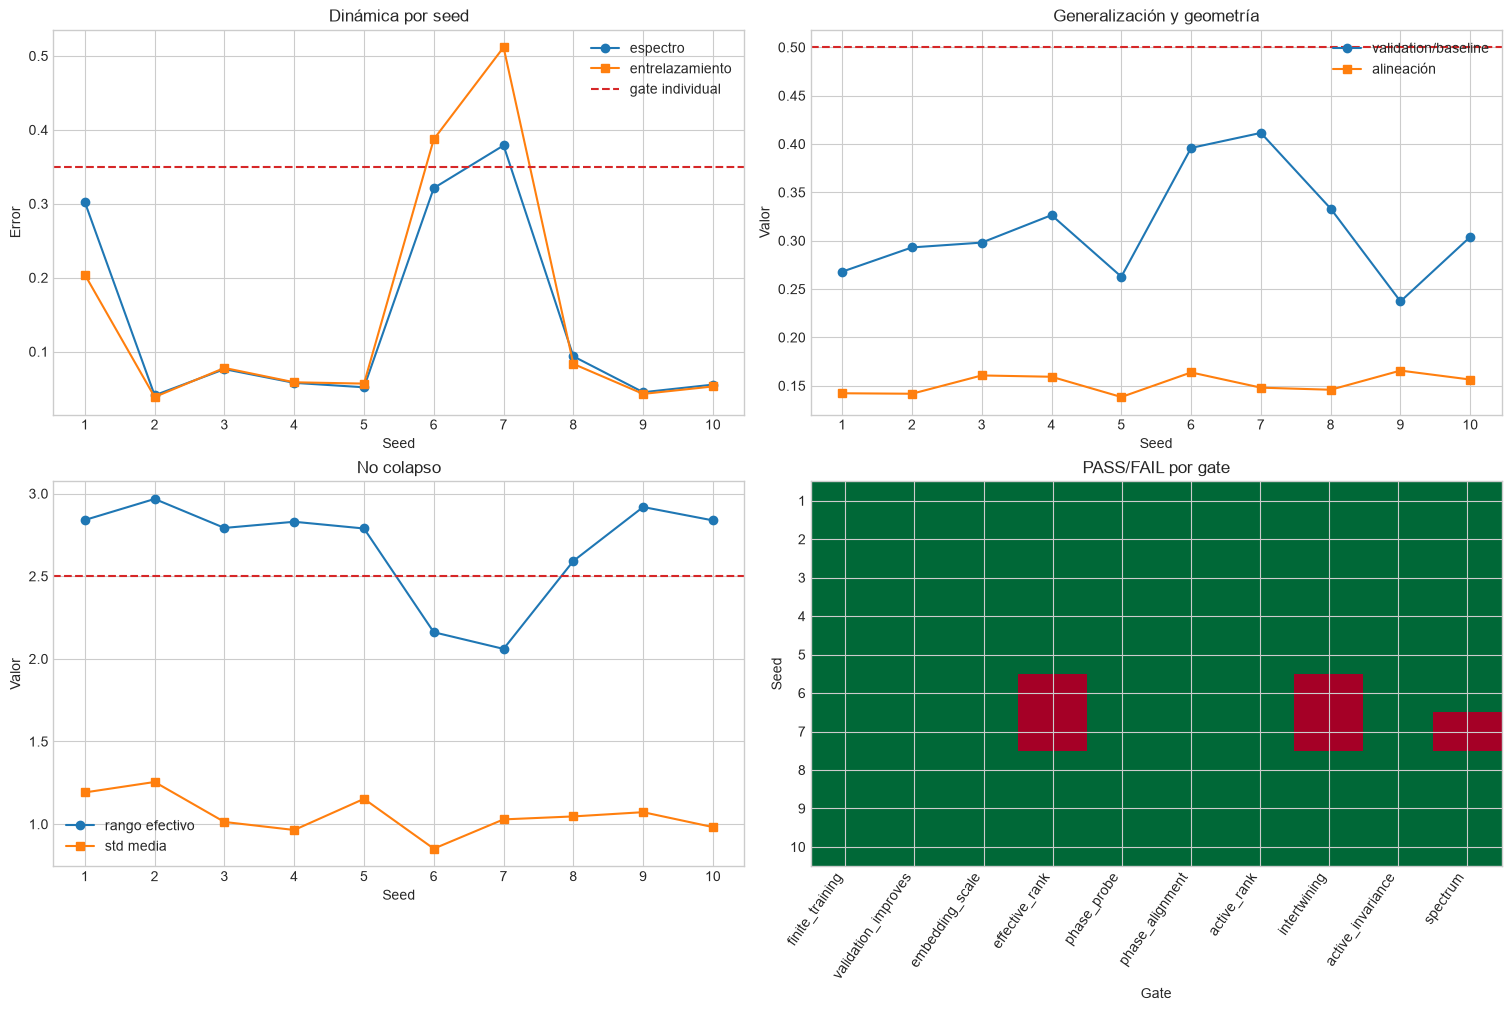

## Análisis del resultado

- Gate multi-seed: **PASS**.
- Seeds exitosas: **8/10** (mínimo predeclarado: `8`).
- Mediana validation/baseline: **0.301**.
- Mediana de rango efectivo / alineación: **2.811 / 0.152**.
- Mediana de entrelazamiento / espectro: **0.068 / 0.067** (máximo agregado: `0.20 / 0.20`).
- Peor entrelazamiento / espectro: **0.512 / 0.379**.
- Fallos individuales: **seed 6: effective_rank, intertwining; seed 7: effective_rank, intertwining, spectrum**.

La receta permaneció congelada para las 10 seeds nuevas. Esta etapa mide robustez de desarrollo; test no se construye y el resultado no es todavía held-out.


In [5]:
seed_axis = np.array(seeds)
fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
axes[0, 0].plot(seed_axis, [result["spectral_max_absolute_error"] for result in seed_results], marker="o", label="espectro")
axes[0, 0].plot(seed_axis, [result["intertwining_error"] for result in seed_results], marker="s", label="entrelazamiento")
axes[0, 0].axhline(raw["gates"]["maximum_spectral_error"], color="tab:red", linestyle="--", label="gate individual")
axes[0, 0].set(title="Dinámica por seed", xlabel="Seed", ylabel="Error", xticks=seed_axis)
axes[0, 0].legend()

axes[0, 1].plot(seed_axis, [result["validation_loss_ratio"] for result in seed_results], marker="o", label="validation/baseline")
axes[0, 1].plot(seed_axis, [result["phase_alignment_error"] for result in seed_results], marker="s", label="alineación")
axes[0, 1].axhline(raw["gates"]["maximum_validation_loss_ratio"], color="tab:red", linestyle="--")
axes[0, 1].set(title="Generalización y geometría", xlabel="Seed", ylabel="Valor", xticks=seed_axis)
axes[0, 1].legend()

axes[1, 0].plot(seed_axis, [result["effective_rank"] for result in seed_results], marker="o", label="rango efectivo")
axes[1, 0].plot(seed_axis, [result["embedding_std_mean"] for result in seed_results], marker="s", label="std media")
axes[1, 0].axhline(raw["gates"]["minimum_effective_rank"], color="tab:red", linestyle="--")
axes[1, 0].set(title="No colapso", xlabel="Seed", ylabel="Valor", xticks=seed_axis)
axes[1, 0].legend()

gate_names = list(seed_results[0]["gate_checks"])
gate_matrix = np.array([[result["gate_checks"][name] for name in gate_names] for result in seed_results], dtype=float)
axes[1, 1].imshow(gate_matrix, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
axes[1, 1].set(title="PASS/FAIL por gate", xlabel="Gate", ylabel="Seed", xticks=np.arange(len(gate_names)), yticks=np.arange(len(seeds)), yticklabels=seeds)
axes[1, 1].set_xticklabels(gate_names, rotation=55, ha="right")
plt.show()

failed_description = "; ".join(f"seed {result['seed']}: {', '.join(result['failed_gates'])}" for result in seed_results if not result["passed"]) or "ninguna"
display(Markdown(f"""## Análisis del resultado

- Gate multi-seed: **{'PASS' if multi_seed_gate_passed else 'FAIL'}**.
- Seeds exitosas: **{successful_seeds}/{len(seed_results)}** (mínimo predeclarado: `{aggregate_config['minimum_successful_seeds']}`).
- Mediana validation/baseline: **{summary['median_validation_loss_ratio']:.3f}**.
- Mediana de rango efectivo / alineación: **{summary['median_effective_rank']:.3f} / {summary['median_phase_alignment_error']:.3f}**.
- Mediana de entrelazamiento / espectro: **{median_intertwining_error:.3f} / {median_spectral_error:.3f}** (máximo agregado: `0.20 / 0.20`).
- Peor entrelazamiento / espectro: **{summary['worst_intertwining_error']:.3f} / {summary['worst_spectral_error']:.3f}**.
- Fallos individuales: **{failed_description}**.

La receta permaneció congelada para las 10 seeds nuevas. Esta etapa mide robustez de desarrollo; test no se construye y el resultado no es todavía held-out.
"""))

In [6]:
assert multi_seed_gate_passed